##### Copyright 2020 The TensorFlow Authors.

*Notebook adaptation: narrative and interpretation revised; executable code preserved unchanged.*

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# 🔎 Image Classification Interpretability with Integrated Gradients

## Business use case

A high-confidence image classification is useful, but it does not tell an engineer **why** the model reached that decision. Before a computer-vision model is trusted in production, teams need a way to inspect whether the prediction is driven by the object itself, by a sensible visual feature, or by an accidental shortcut in the background.

This notebook uses **Integrated Gradients (IG)** to inspect the pixel-level evidence behind predictions from a pretrained **Inception V1** classifier. The practical question is simple: *when the model says “coyote,” what parts of the image actually contributed to that output?*

## Principal objective

The objective is to implement Integrated Gradients from first principles, visualize local feature attributions, and use those attributions to assess whether the model is relying on plausible image regions. The workflow also makes an important boundary explicit: **feature attribution improves interpretability, but it does not establish causality**.

The notebook is adapted from the TensorFlow Integrated Gradients tutorial. The portfolio narrative focuses on the engineering reasoning, the saved outputs, and the implications for model review.

### Reference implementation

The underlying implementation follows TensorFlow's Integrated Gradients tutorial and uses the pretrained Inception V1 model from TensorFlow Hub. The purpose of this portfolio version is to document how the technique can support model debugging and review rather than to present the classifier itself as a newly trained model.

### Why Integrated Gradients

Integrated Gradients attributes a prediction back to the input features by accumulating gradients along a path between a **baseline input** and the observed input. For images, the result is a pixel-level attribution map.

That makes IG useful for questions that accuracy or confidence cannot answer on their own: Is the model looking at the animal, the background, a watermark, a border, or another visual artifact? The answer can reveal plausible reasoning, shortcut learning, or data issues worth investigating before deployment.

Because the explanation is local, the result should be interpreted as evidence about **this prediction on this input**, not as a global description of everything the model has learned.

## Step 1 — Set up the interpretability workflow

In [ ]:
import matplotlib.pylab as plt
import numpy as np
!pip install tf_keras -q
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tensorflow as tf
import tensorflow_hub as hub

### Load the pretrained classifier

The analysis uses a pretrained **Inception V1** ImageNet classifier. A pretrained network is appropriate here because the engineering focus is not model training; it is the explanation layer placed on top of an existing differentiable model.

In [ ]:
model = tf.keras.Sequential([
    hub.KerasLayer(
        name='inception_v1',
        handle='https://tfhub.dev/google/imagenet/inception_v1/classification/4',
        ##input_shape=(224,224,3),
        trainable=False),
])
model.build([None, 224, 224, 3])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v1 (KerasLayer)   (None, 1001)              6633209   
                                                                 
Total params: 6633209 (25.30 MB)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 6633209 (25.30 MB)
_________________________________________________________________


### Model interface

Inception V1 expects images with shape `(224, 224, 3)` and pixel values scaled to `[0, 1]`. The model returns logits over **1,001 ImageNet classes**. Applying softmax converts those logits into class probabilities, which provides the target output that Integrated Gradients will explain.

Keeping the model interface explicit matters for interpretability work: attribution is only meaningful when the preprocessing, target class, and output being explained are clearly defined.

In [ ]:
def load_imagenet_labels(file_path):
  labels_file = tf.keras.utils.get_file('ImageNetLabels.txt', file_path)
  with open(labels_file) as reader:
    f = reader.read()
    labels = f.splitlines()
  return np.array(labels)

In [ ]:
imagenet_labels = load_imagenet_labels('https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')

10484/10484 [==============================] - 0s 0us/step


## Step 2 — Load and preprocess evaluation images

Two images are used in the saved workflow: a **fireboat** and a **coyote**. Each image is decoded, converted to floating point, and resized with padding to the model's expected input dimensions.

Using more than one image helps separate the mechanics of the explanation method from the interpretation of a single example.

In [ ]:
def read_image(file_name):
  image = tf.io.read_file(file_name)
  image = tf.io.decode_jpeg(image, channels=3)
  image = tf.image.convert_image_dtype(image, tf.float32)
  image = tf.image.resize_with_pad(image, target_height=224, target_width=224)
  return image

In [ ]:
import urllib.request
img_url = {
    'Fireboat': 'http://storage.googleapis.com/download.tensorflow.org/example_images/San_Francisco_fireboat_showing_off.jpg',
    'Coyote': 'https://upload.wikimedia.org/wikipedia/commons/c/ce/Canis_latrans_%28Yosemite%2C_2009%29.jpg',
}

#img_paths = {name: tf.keras.utils.get_file(name, url) for (name, url) in img_url.items()}
img_paths = {}
for name, url in img_url.items():
    fpath = f'/tmp/{name}.jpg'
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (research/educational use)'})
    with urllib.request.urlopen(req) as response, open(fpath, 'wb') as out_file:
        out_file.write(response.read())
    img_paths[name] = fpath
img_name_tensors = {name: read_image(img_path) for (name, img_path) in img_paths.items()}

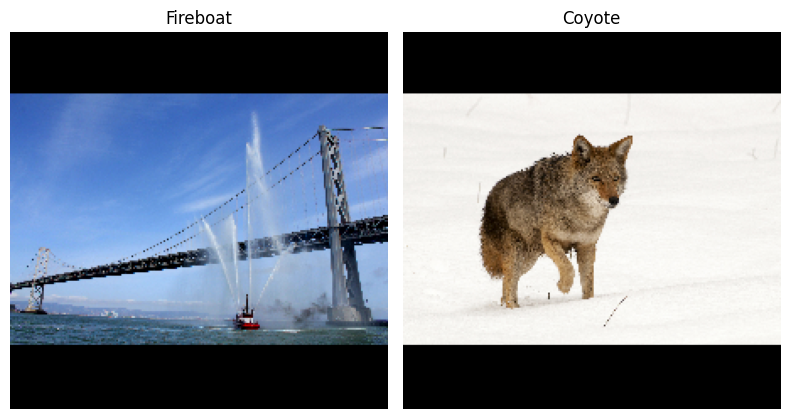

In [ ]:
plt.figure(figsize=(8, 8))
for n, (name, img_tensors) in enumerate(img_name_tensors.items()):
  ax = plt.subplot(1, 2, n+1)
  ax.imshow(img_tensors)
  ax.set_title(name)
  ax.axis('off')
plt.tight_layout()

## Step 3 — Establish the prediction baseline

Before explaining a model output, the prediction itself needs to be recorded. The next cells retrieve the top three labels and probabilities for each image.

This creates a useful separation between two questions: **what did the model predict?** and **what visual evidence contributed to that prediction?**

In [ ]:
def top_k_predictions(img, k=3):
  image_batch = tf.expand_dims(img, 0)
  predictions = model(image_batch)
  probs = tf.nn.softmax(predictions, axis=-1)
  top_probs, top_idxs = tf.math.top_k(input=probs, k=k)
  top_labels = imagenet_labels[tuple(top_idxs)]
  return top_labels, top_probs[0]

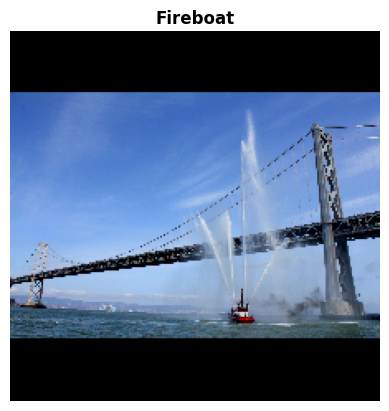

fireboat: 32.6%
pier: 12.7%
suspension bridge: 5.7%


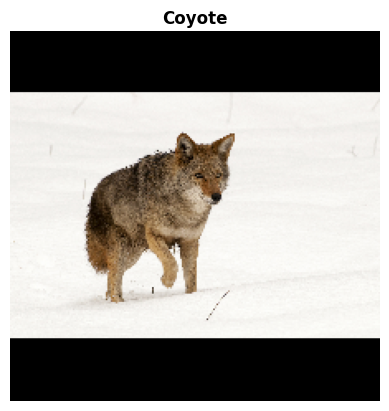

coyote: 90.1%
timber wolf: 5.4%
grey fox: 1.7%


In [ ]:
for (name, img_tensor) in img_name_tensors.items():
  plt.imshow(img_tensor)
  plt.title(name, fontweight='bold')
  plt.axis('off')
  plt.show()

  pred_label, pred_prob = top_k_predictions(img_tensor)
  for label, prob in zip(pred_label, pred_prob):
    print(f'{label}: {prob:0.1%}')

## Step 4 — Build Integrated Gradients from first principles

A raw gradient describes how a small local change in an input feature changes the model output. For deep networks, relying on a single local gradient can be misleading because gradients may saturate.

Integrated Gradients addresses this by accumulating gradients along a path from a baseline image to the actual input. The following cells build that computation in stages so that the explanation can be inspected rather than treated as a black-box utility.

In [ ]:
def f(x):
  """A simplified model function."""
  return tf.where(x < 0.8, x, 0.8)

def interpolated_path(x):
  """A straight line path."""
  return tf.zeros_like(x)

x = tf.linspace(start=0.0, stop=1.0, num=6)
y = f(x)

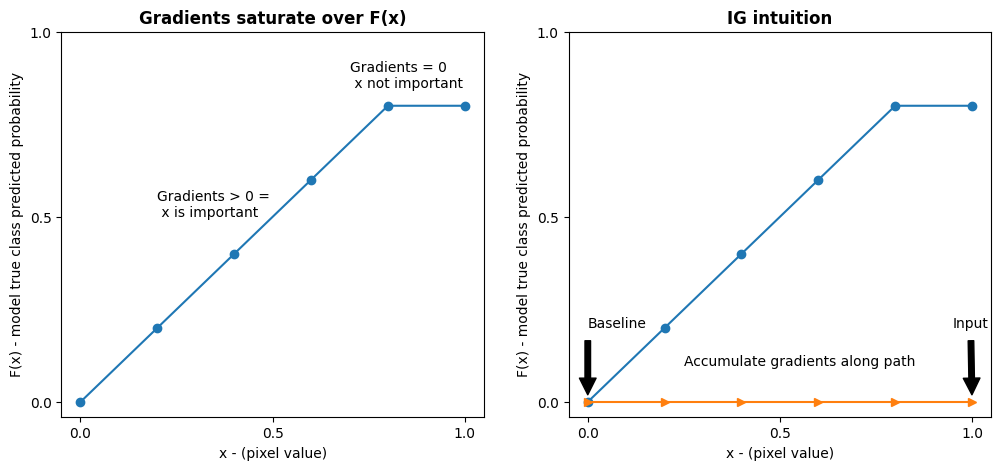

In [ ]:
#@title
fig = plt.figure(figsize=(12, 5))
ax0 = fig.add_subplot(121)
ax0.plot(x, f(x), marker='o')
ax0.set_title('Gradients saturate over F(x)', fontweight='bold')
ax0.text(0.2, 0.5, 'Gradients > 0 = \n x is important')
ax0.text(0.7, 0.85, 'Gradients = 0 \n x not important')
ax0.set_yticks(tf.range(0, 1.5, 0.5))
ax0.set_xticks(tf.range(0, 1.5, 0.5))
ax0.set_ylabel('F(x) - model true class predicted probability')
ax0.set_xlabel('x - (pixel value)')

ax1 = fig.add_subplot(122)
ax1.plot(x, f(x), marker='o')
ax1.plot(x, interpolated_path(x), marker='>')
ax1.set_title('IG intuition', fontweight='bold')
ax1.text(0.25, 0.1, 'Accumulate gradients along path')
ax1.set_ylabel('F(x) - model true class predicted probability')
ax1.set_xlabel('x - (pixel value)')
ax1.set_yticks(tf.range(0, 1.5, 0.5))
ax1.set_xticks(tf.range(0, 1.5, 0.5))
ax1.annotate('Baseline', xy=(0.0, 0.0), xytext=(0.0, 0.2),
             arrowprops=dict(facecolor='black', shrink=0.1))
ax1.annotate('Input', xy=(1.0, 0.0), xytext=(0.95, 0.2),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.show();

The toy example illustrates gradient saturation. A feature can be important to the final prediction even when the local gradient near the observed input is close to zero. IG reduces this problem by integrating information across the full path from baseline to input rather than using only the endpoint gradient.

### Define a baseline

The baseline represents the absence of the input signal. Here, the baseline is a black image with the same dimensions as the model input.

Baseline choice is part of the explanation design. An attribution map does not exist independently of that choice, so a production workflow should document and test whether the selected baseline produces stable, sensible explanations.

In [ ]:
baseline = tf.zeros(shape=(224,224,3))

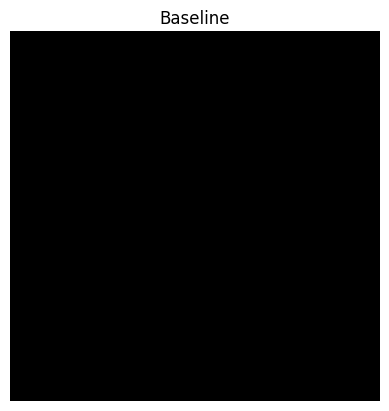

In [ ]:
plt.imshow(baseline)
plt.title("Baseline")
plt.axis('off')
plt.show()

### Translate the method into computation

Integrated Gradients can be written as:

$IntegratedGradients_{i}(x) = (x_{i} - x'_{i})\times\int_{\alpha=0}^{1}\frac{\partial F(x' + \alpha(x-x'))}{\partial x_i}d\alpha$

where $x$ is the observed image, $x'$ is the baseline, $F$ is the model output for the target class, and $i$ identifies an input feature.

In practice, the integral is approximated numerically by evaluating gradients at multiple points between the baseline and the observed image. Increasing the number of interpolation steps generally improves the approximation at additional computational cost.

### Interpolate between baseline and input

The first computational component is the interpolation path. A sequence of values of $\alpha$ moves the input smoothly from the baseline toward the original image.

Each interpolated image represents one point along that path. Instead of asking only what the gradient looks like at the final image, the method observes how the target prediction changes as the visual signal is gradually introduced.

In [ ]:
m_steps=50
alphas = tf.linspace(start=0.0, stop=1.0, num=m_steps+1) # Generate m_steps intervals for integral_approximation() below.

In [ ]:
def interpolate_images(baseline,
                       image,
                       alphas):
  alphas_x = alphas[:, tf.newaxis, tf.newaxis, tf.newaxis]
  baseline_x = tf.expand_dims(baseline, axis=0)
  input_x = tf.expand_dims(image, axis=0)
  delta = input_x - baseline_x
  images = baseline_x +  alphas_x * delta
  return images

The interpolation function is now applied to the fireboat example using the previously defined black baseline.

In [ ]:
interpolated_images = interpolate_images(
    baseline=baseline,
    image=img_name_tensors['Fireboat'],
    alphas=alphas)

Visualizing intermediate images provides an intuitive check: as $\alpha$ increases, the input should transition smoothly from the baseline to the original image.

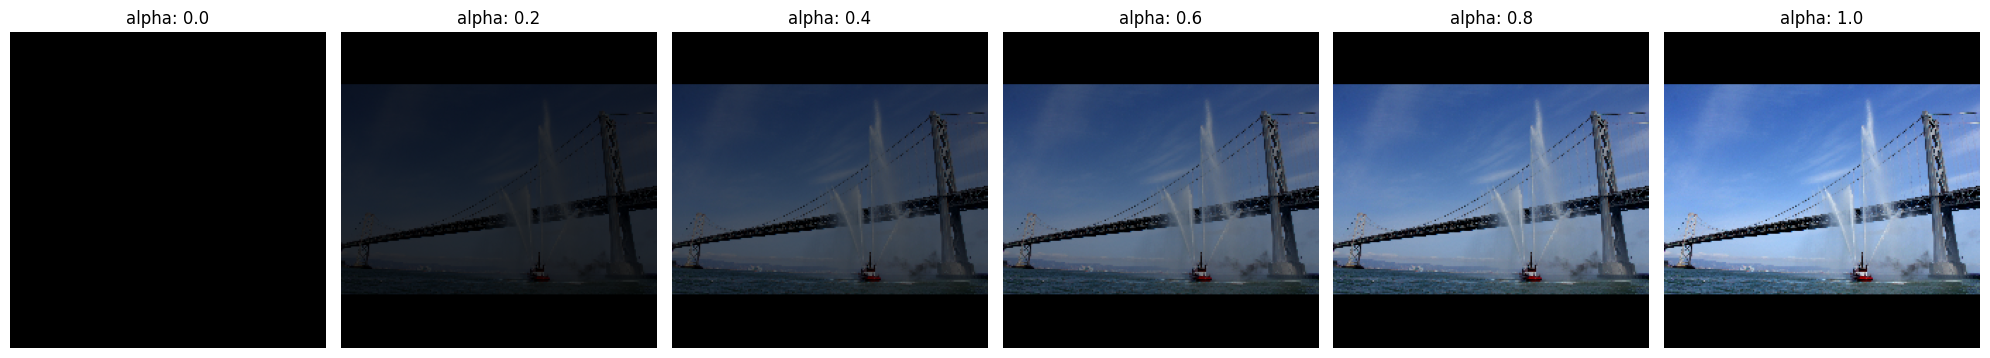

In [ ]:
fig = plt.figure(figsize=(20, 20))

i = 0
for alpha, image in zip(alphas[0::10], interpolated_images[0::10]):
  i += 1
  plt.subplot(1, len(alphas[0::10]), i)
  plt.title(f'alpha: {alpha:.1f}')
  plt.imshow(image)
  plt.axis('off')

plt.tight_layout();

### Compute gradients along the path

For each interpolated image, the workflow computes the gradient of the target-class probability with respect to every input pixel. Large gradient magnitudes indicate locations where small changes are associated with larger changes in the selected model output at that point on the path.

The result retains the spatial structure of the image: every interpolation step produces a gradient value for each pixel and color channel.

TensorFlow's `GradientTape` is used to obtain these derivatives directly from the differentiable model.

In [ ]:
def compute_gradients(images, target_class_idx):
  with tf.GradientTape() as tape:
    tape.watch(images)
    logits = model(images)
    probs = tf.nn.softmax(logits, axis=-1)[:, target_class_idx]
  return tape.gradient(probs, images)

The next computation evaluates the gradients along the fireboat interpolation path for the target class used by the saved notebook.

In [ ]:
path_gradients = compute_gradients(
    images=interpolated_images,
    target_class_idx=555)

The gradient tensor has one gradient map per interpolated image, with the same height, width, and RGB-channel structure as the original input.

In [ ]:
print(path_gradients.shape)

(51, 224, 224, 3)


### Inspect gradient saturation

The saved plots compare target-class probability and gradient magnitude across the interpolation path. This diagnostic matters because it shows why endpoint gradients alone can miss relevant evidence once the model output has entered a flatter region.

In [ ]:
pred = model(interpolated_images)
pred_proba = tf.nn.softmax(pred, axis=-1)[:, 555]

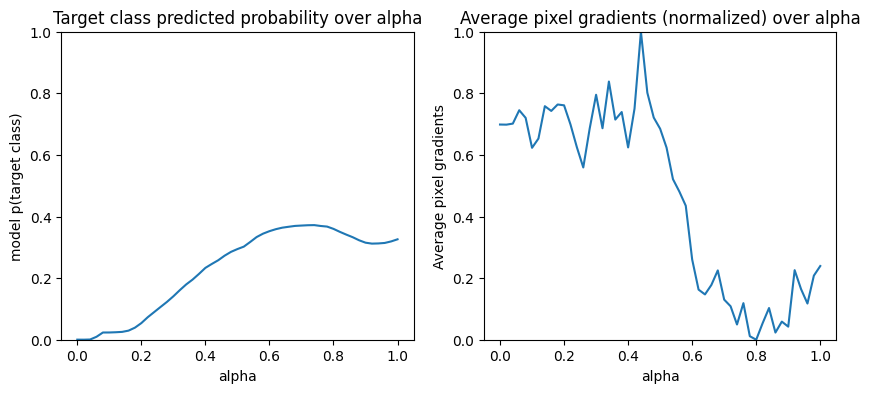

In [ ]:
#@title
plt.figure(figsize=(10, 4))
ax1 = plt.subplot(1, 2, 1)
ax1.plot(alphas, pred_proba)
ax1.set_title('Target class predicted probability over alpha')
ax1.set_ylabel('model p(target class)')
ax1.set_xlabel('alpha')
ax1.set_ylim([0, 1])

ax2 = plt.subplot(1, 2, 2)
# Average across interpolation steps
average_grads = tf.reduce_mean(path_gradients, axis=[1, 2, 3])
# Normalize gradients to 0 to 1 scale. E.g., (x - min(x))/(max(x)-min(x))
average_grads_norm = (average_grads-tf.math.reduce_min(average_grads))/(tf.math.reduce_max(average_grads)-tf.reduce_min(average_grads))
ax2.plot(alphas, average_grads_norm)
ax2.set_title('Average pixel gradients (normalized) over alpha')
ax2.set_ylabel('Average pixel gradients')
ax2.set_xlabel('alpha')
ax2.set_ylim([0, 1]);

The probability curve rises as the fireboat image is introduced and then becomes flatter. The accompanying gradient behavior reinforces the motivation for integrating information across the entire path instead of relying on a single derivative at the final input.

### Approximate the integral

The notebook uses the trapezoidal rule to average neighboring gradients along the interpolation path. This produces the numerical approximation required by Integrated Gradients while keeping the implementation transparent.

The integrated result summarizes the accumulated sensitivity of the target prediction along the path from baseline to input.

In [ ]:
def integral_approximation(gradients):
  # riemann_trapezoidal
  grads = (gradients[:-1] + gradients[1:]) / tf.constant(2.0)
  integrated_gradients = tf.math.reduce_mean(grads, axis=0)
  return integrated_gradients

The integral approximation collapses the path dimension and returns a gradient tensor aligned with the original image dimensions.

In [ ]:
ig = integral_approximation(
    gradients=path_gradients)

The resulting tensor has the same `(224, 224, 3)` shape as the source image, which allows the attribution values to be mapped back to specific pixel locations.

In [ ]:
print(ig.shape)

(224, 224, 3)


### Assemble a reusable Integrated Gradients function

The individual components are combined into a reusable function: generate interpolation points, compute gradients in batches, approximate the integral, and scale the result by the difference between the original input and the baseline.

Conceptually, the implementation follows the same path-based attribution formula used in the previous sections; the next cell packages the sequence into one callable workflow.

The implementation can be read as five operations:

- generate interpolation coefficients,
- construct inputs between baseline and observed image,
- compute target-class gradients,
- average the gradients to approximate the integral,
- scale the result back to the original input space.

This decomposition is useful for engineering review because each part can be inspected independently when explanations look unstable or counterintuitive.

In [ ]:
def integrated_gradients(baseline,
                         image,
                         target_class_idx,
                         m_steps=50,
                         batch_size=32):
  # Generate alphas.
  alphas = tf.linspace(start=0.0, stop=1.0, num=m_steps+1)

  # Collect gradients.
  gradient_batches = []

  # Iterate alphas range and batch computation for speed, memory efficiency, and scaling to larger m_steps.
  for alpha in tf.range(0, len(alphas), batch_size):
    from_ = alpha
    to = tf.minimum(from_ + batch_size, len(alphas))
    alpha_batch = alphas[from_:to]

    gradient_batch = one_batch(baseline, image, alpha_batch, target_class_idx)
    gradient_batches.append(gradient_batch)

  # Concatenate path gradients together row-wise into single tensor.
  total_gradients = tf.concat(gradient_batches, axis=0)

  # Integral approximation through averaging gradients.
  avg_gradients = integral_approximation(gradients=total_gradients)

  # Scale integrated gradients with respect to input.
  integrated_gradients = (image - baseline) * avg_gradients

  return integrated_gradients

In [ ]:
@tf.function
def one_batch(baseline, image, alpha_batch, target_class_idx):
    # Generate interpolated inputs between baseline and input.
    interpolated_path_input_batch = interpolate_images(baseline=baseline,
                                                       image=image,
                                                       alphas=alpha_batch)

    # Compute gradients between model outputs and interpolated inputs.
    gradient_batch = compute_gradients(images=interpolated_path_input_batch,
                                       target_class_idx=target_class_idx)
    return gradient_batch

In [ ]:
ig_attributions = integrated_gradients(baseline=baseline,
                                       image=img_name_tensors['Fireboat'],
                                       target_class_idx=555,
                                       m_steps=240)

The final attribution tensor preserves the dimensions of the input image, allowing the contribution map to be rendered directly over the original pixels.

In [ ]:
print(ig_attributions.shape)

(224, 224, 3)


The number of interpolation steps is a numerical-accuracy choice. Too few steps can produce a coarse approximation; more steps increase computation. In a production explainability pipeline, this parameter should be validated for convergence rather than selected only by convention.

## Step 5 — Visualize and interpret the attributions

The visualization sums the absolute attribution values across RGB channels to create a two-dimensional mask, then overlays that mask on the original image. This makes the model's strongest local evidence visible to a reviewer.

In [ ]:
#@title
def plot_img_attributions(baseline,
                          image,
                          target_class_idx,
                          m_steps=50,
                          cmap=None,
                          overlay_alpha=0.4):

  attributions = integrated_gradients(baseline=baseline,
                                      image=image,
                                      target_class_idx=target_class_idx,
                                      m_steps=m_steps)

  # Sum of the attributions across color channels for visualization.
  # The attribution mask shape is a grayscale image with height and width
  # equal to the original image.
  attribution_mask = tf.reduce_sum(tf.math.abs(attributions), axis=-1)

  fig, axs = plt.subplots(nrows=2, ncols=2, squeeze=False, figsize=(8, 8))

  axs[0, 0].set_title('Baseline image')
  axs[0, 0].imshow(baseline)
  axs[0, 0].axis('off')

  axs[0, 1].set_title('Original image')
  axs[0, 1].imshow(image)
  axs[0, 1].axis('off')

  axs[1, 0].set_title('Attribution mask')
  axs[1, 0].imshow(attribution_mask, cmap=cmap)
  axs[1, 0].axis('off')

  axs[1, 1].set_title('Overlay')
  axs[1, 1].imshow(attribution_mask, cmap=cmap)
  axs[1, 1].imshow(image, alpha=overlay_alpha)
  axs[1, 1].axis('off')

  plt.tight_layout()
  return fig

### Fireboat interpretation

For the fireboat example, the attribution map emphasizes the **water cannons and water jets**. The prediction is correct, but the explanation is more informative than correctness alone: the model appears to rely strongly on a particular visual pattern associated with fireboats rather than on the complete vessel.

That is exactly the kind of result worth testing with counterexamples—for example, fireboats without active water jets—to determine whether the classifier has learned a robust object concept or a narrower shortcut.

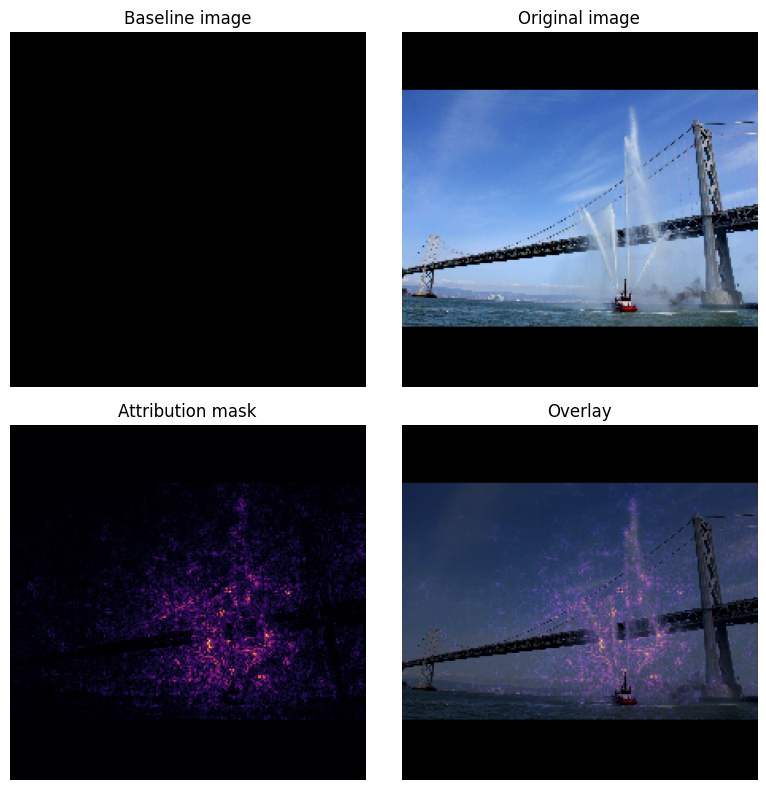

In [ ]:
_ = plot_img_attributions(image=img_name_tensors['Fireboat'],
                          baseline=baseline,
                          target_class_idx=555,
                          m_steps=240,
                          cmap=plt.cm.inferno,
                          overlay_alpha=0.4)

### Coyote interpretation

The saved classifier output assigns **90.1% predicted probability to `coyote`**, followed by **5.4% for `timber wolf`** and **1.7% for `grey fox`**. The accompanying activity originally referred to the 90.1% value as “accuracy”; in this context, it is more precisely the model's predicted probability for this individual image.

The attribution mask is concentrated mainly on the **animal's body contour and back**, with additional signal around the **face and ears**. The surrounding snow receives comparatively little emphasis. A small area near a branch also receives some attribution, which is a useful reminder that explanations can surface incidental visual cues alongside the dominant object features.

Taken together, the prediction and attribution are encouraging for this example: the strongest evidence lies on the coyote rather than broadly across the background. That is still a **local** observation. One image is not enough to establish that the model will behave reliably across different coyotes, seasons, backgrounds, camera conditions, or visually similar species.

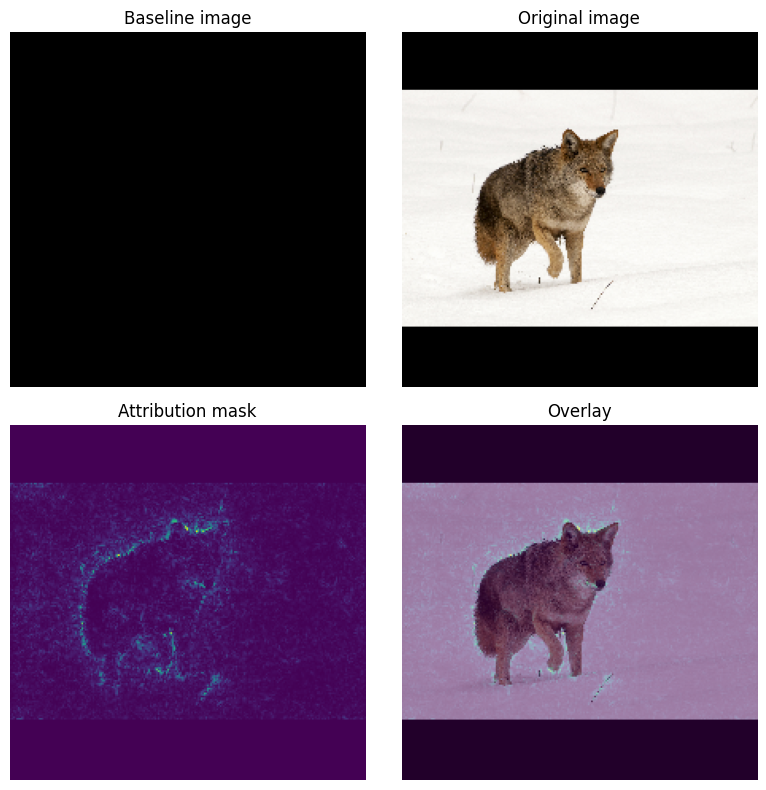

In [ ]:
_ = plot_img_attributions(image=img_name_tensors['Coyote'],
                          baseline=baseline,
                          target_class_idx=389,
                          m_steps=55,
                          cmap=plt.cm.viridis,
                          overlay_alpha=0.5)

## Step 6 — Translate attribution into engineering conclusions

### Technical conclusions

Integrated Gradients adds a layer of evidence that class probability alone cannot provide. In the saved examples, the method reveals which image regions are associated with the selected class output and helps distinguish plausible object evidence from potentially fragile visual shortcuts.

Several technical points matter before treating these explanations as production-grade:

- IG is **local**: it explains one prediction at a time and does not provide a global model summary.
- The result depends on the **baseline** and the numerical approximation used.
- Attribution magnitude does not automatically explain feature interactions or the complete internal reasoning of the network.
- A visually plausible attribution is a diagnostic signal, not proof that the model is robust.
- Integrated Gradients is an **interpretability method, not a causal estimator**. It describes sensitivity of the model output to input features along a constructed path; it does not prove that a highlighted feature causes the real-world class or outcome.

### Business and risk conclusions

For teams deploying computer vision, attribution can improve model review by making failure modes easier to discuss with engineers, domain experts, auditors, and product owners. A high-confidence prediction that focuses on an irrelevant background artifact should trigger investigation even when the class label is correct.

This is especially valuable when model errors have material consequences. Explainability can support debugging, model acceptance testing, incident review, and human oversight by showing reviewers what evidence the model appears to use. The technique should complement—not replace—robust validation across representative data, stress tests, and explicit performance monitoring.

## Step 7 — Define limitations and next steps

A stronger production workflow would test attribution stability across multiple images, classes, backgrounds, and baseline choices. It would also compare explanations for correct predictions, incorrect predictions, and ambiguous cases rather than evaluating only visually successful examples.

The next useful experiments would be to:

- repeat the analysis on a representative image set instead of isolated examples,
- compare attribution patterns across correct and incorrect classifications,
- test images where expected visual cues are deliberately removed or altered,
- evaluate whether the explanation changes materially under different baselines,
- add quantitative checks for attribution convergence and stability,
- pair interpretability results with ordinary model-quality and subgroup-performance metrics.

The key portfolio takeaway is that **prediction confidence answers “how strongly did the model choose this label?” while Integrated Gradients helps answer “which input regions contributed to that choice?”** Neither question, by itself, answers a causal question about the real world.